#📌 Extracción

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [7]:
df.shape

(7267, 6)

#🔧 Transformación

In [8]:
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


#Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente


In [10]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


In [11]:
import requests
import pandas as pd

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

df = pd.json_normalize(data)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [12]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [13]:
df.columns = df.columns.str.replace('.', '_', regex=False)
df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')

In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [15]:
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

In [16]:
df['account_Charges_Total'].dtype

dtype('float64')

In [17]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [18]:
df.dropna(subset=['account_Charges_Total'], inplace=True)

In [19]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [20]:
df['Churn'].dtype

dtype('float64')

In [21]:
df['Churn'].mean()

np.float64(0.26578498293515357)

#Validación de estructura y tipos de datos

Tras revisar la estructura del dataset, se observó que todas las columnas cuentan con registros completos. Sin embargo, la variable account_Charges_Total se encontraba almacenada como texto, por lo que fue convertida a formato numérico para permitir análisis estadísticos adecuados.

Asimismo, la variable Churn fue transformada a formato binario (1 = canceló, 0 = no canceló) para facilitar el análisis de evasión.

Con estas transformaciones, el dataset quedó correctamente estructurado y listo para el análisis exploratorio.

In [22]:
df.groupby('account_Contract')['Churn'].mean()

,Churn
account_Contract,
Month-to-month,0.427097
One year,0.112772
Two year,0.028487


In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df['account_Contract'].unique()
df['internet_InternetService'].unique()
df['account_PaymentMethod'].unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

#Verificación de inconsistencias en variables categóricas

Se revisaron las categorías de variables clave como *account_PaymentMethod*, *account_Contract* e *internet_InternetService*.

No se identificaron inconsistencias en los valores, tales como errores de escritura, espacios adicionales o duplicación de categorías.

Por tanto, las variables categóricas se consideran limpias y adecuadas para el análisis posterior.

In [25]:
df['Cuentas_Diarias'] = df['account_Charges_Monthly'] / 30

In [26]:
df[['account_Charges_Monthly', 'Cuentas_Diarias']].head()

,account_Charges_Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [27]:
df['Cuentas_Diarias'] = df['Cuentas_Diarias'].round(2)

In [28]:
df[['account_Charges_Monthly', 'Cuentas_Diarias']].head()

,account_Charges_Monthly,Cuentas_Diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


In [29]:
binary_cols = [
    'customer_Partner',
    'customer_Dependents',
    'phone_PhoneService',
    'account_PaperlessBilling'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

In [30]:
df[binary_cols].head()

,customer_Partner,customer_Dependents,phone_PhoneService,account_PaperlessBilling
0,1,1,1,1
1,0,0,1,0
2,0,0,1,1
3,1,0,1,1
4,1,0,1,1


In [31]:
df.rename(columns={
    'customer_tenure': 'Antiguedad_meses',
    'account_Charges_Monthly': 'Cargo_Mensual',
    'account_Charges_Total': 'Cargo_Total',
    'account_Contract': 'Tipo_Contrato',
    'account_PaymentMethod': 'Metodo_Pago'
}, inplace=True)

In [33]:
df['Metodo_Pago'] = df['Metodo_Pago'].replace({
    'Credit card (automatic)': 'Tarjeta automática',
    'Bank transfer (automatic)': 'Transferencia automática',
    'Electronic check': 'Cheque electrónico',
    'Mailed check': 'Cheque físico'
})

#Estandarización y transformación de variables

Se realizó una estandarización parcial de las variables categóricas, convirtiendo valores binarios como "Yes" y "No" en formato numérico (1 y 0), facilitando así su análisis estadístico y modelado posterior.

Asimismo, se renombraron algunas columnas clave para mejorar la claridad y comprensión del dataset, permitiendo una mejor comunicación de resultados en etapas posteriores.

Estas transformaciones no alteran la información original, pero mejoran significativamente la consistencia y legibilidad del análisis.

#📊 Carga y análisis

In [34]:
df.describe()

,Churn,customer_SeniorCitizen,customer_Partner,customer_Dependents,Antiguedad_meses,phone_PhoneService,account_PaperlessBilling,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7032.000000,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.265785,0.1629,0.483600,0.299063,32.395535,0.902839,0.593716,64.755423,2280.634213,2.158467
std,0.441782,0.3693,0.499765,0.457879,24.558067,0.296197,0.491173,30.125739,2268.632997,1.004282
min,0.000000,0.0000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.0000,0.000000,0.000000,9.000000,1.000000,0.000000,35.450000,400.225000,1.180000
50%,0.000000,0.0000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.340000
75%,1.000000,0.0000,1.000000,1.000000,55.000000,1.000000,1.000000,89.900000,3785.300000,3.000000
max,1.000000,1.0000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [40]:
df[['Antiguedad_meses', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias']].describe()

,Antiguedad_meses,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7256.000000,7256.000000,7256.000000,7256.000000
mean,32.395535,64.755423,2280.634213,2.158467
std,24.558067,30.125739,2268.632997,1.004282
min,1.000000,18.250000,18.800000,0.610000
25%,9.000000,35.450000,400.225000,1.180000
50%,29.000000,70.300000,1391.000000,2.340000
75%,55.000000,89.900000,3785.300000,3.000000
max,72.000000,118.750000,8684.800000,3.960000


In [41]:
df.groupby('Churn')[['Antiguedad_meses', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias']].mean()

,Antiguedad_meses,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
Churn,,,,
0.0,37.650010,61.307408,2555.344141,2.043486
1.0,17.979133,74.441332,1531.796094,2.481450


El análisis descriptivo evidencia que la variable con mayor diferencia entre clientes activos y clientes que cancelan es la antigüedad. Los clientes que presentan churn tienen en promedio 17.9 meses de permanencia, mientras que los clientes activos alcanzan 37.6 meses, lo que sugiere que la cancelación se concentra principalmente en los primeros meses del servicio.

Asimismo, se observa que los clientes que cancelan presentan un cargo mensual promedio más alto ($74.44 frente a $61.30), lo que podría indicar una relación entre el nivel de facturación y la probabilidad de cancelación.

In [42]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0.0,73.421502
1.0,26.578498


Se observa que los clientes que presentan churn tienen menor antigüedad promedio y tienden a presentar diferencias en el cargo mensual en comparación con los clientes activos, lo que sugiere que la permanencia y el nivel de facturación pueden estar asociados al comportamiento de cancelación.


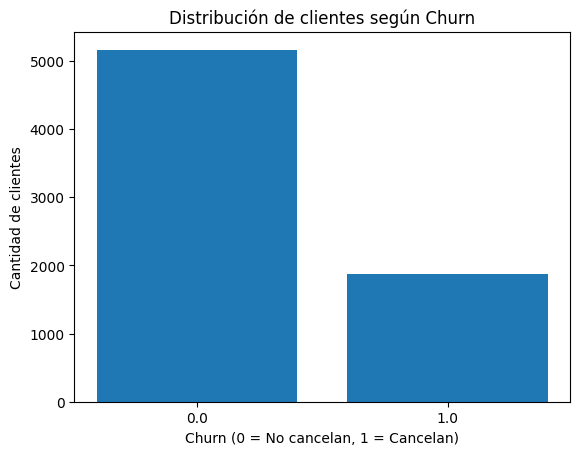

In [43]:
import matplotlib.pyplot as plt

# Contar valores
churn_counts = df['Churn'].value_counts()

# Crear gráfico
plt.figure()
plt.bar(churn_counts.index.astype(str), churn_counts.values)

plt.xlabel("Churn (0 = No cancelan, 1 = Cancelan)")
plt.ylabel("Cantidad de clientes")
plt.title("Distribución de clientes según Churn")

plt.show()

In [44]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0.0,73.421502
1.0,26.578498


La distribución de la variable churn evidencia que la mayoría de los clientes permanecen en el servicio. Sin embargo, aproximadamente una cuarta parte de los clientes presentan evasión, lo que representa una proporción significativa que puede impactar la rentabilidad de la empresa.

In [45]:
pd.crosstab(df['Tipo_Contrato'], df['Churn'], normalize='index') * 100

Churn,0.0,1.0
Tipo_Contrato,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


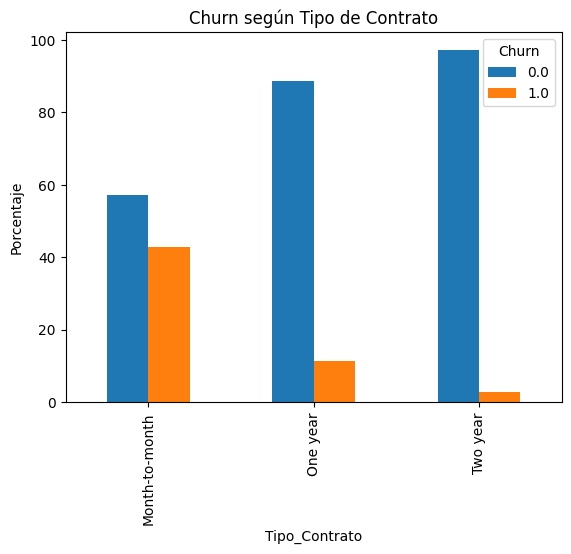

In [46]:
import matplotlib.pyplot as plt

tabla_contrato = pd.crosstab(df['Tipo_Contrato'], df['Churn'], normalize='index') * 100

tabla_contrato.plot(kind='bar')
plt.title("Churn según Tipo de Contrato")
plt.ylabel("Porcentaje")
plt.show()

In [47]:
pd.crosstab(df['Metodo_Pago'], df['Churn'], normalize='index') * 100

Churn,0.0,1.0
Metodo_Pago,,
Cheque electrónico,54.714588,45.285412
Cheque físico,80.798005,19.201995
Tarjeta automática,84.746877,15.253123
Transferencia automática,83.268482,16.731518


Se evidencia que los clientes que utilizan cheque electrónico presentan la mayor tasa de cancelación (45.3%), en contraste con los métodos de pago automáticos, que registran tasas inferiores al 17%. Esto sugiere que la automatización del pago podría ser un factor protector frente a la evasión.

In [48]:
pd.crosstab(df['customer_gender'], df['Churn'], normalize='index') * 100

Churn,0.0,1.0
customer_gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


No se observan diferencias significativas en la tasa de cancelación según el género del cliente, lo que indica que esta variable no representa un factor determinante en la evasión.

In [49]:
pd.crosstab(df['internet_InternetService'], df['Churn'], normalize='index') * 100

Churn,0.0,1.0
internet_InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


El análisis por variables categóricas revela que el churn está fuertemente asociado al método de pago y al tipo de servicio de internet. Los clientes que utilizan cheque electrónico y aquellos que cuentan con servicio de fibra óptica presentan las tasas más altas de cancelación (45.3% y 41.9%, respectivamente). Por el contrario, los métodos de pago automáticos y los servicios DSL muestran menores niveles de evasión.

No se identifican diferencias significativas en la cancelación según el género del cliente.

Los clientes con contrato mensual presentan una probabilidad significativamente mayor de cancelación en comparación con aquellos que tienen contratos a largo plazo, lo que sugiere que los compromisos contractuales más extensos favorecen la retención.

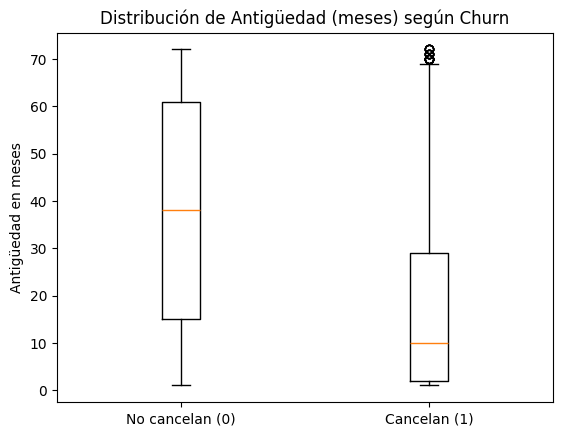

In [50]:
import matplotlib.pyplot as plt

plt.figure()

data_antiguedad = [
    df[df['Churn'] == 0]['Antiguedad_meses'],
    df[df['Churn'] == 1]['Antiguedad_meses']
]

plt.boxplot(data_antiguedad, tick_labels=['No cancelan (0)', 'Cancelan (1)'])

plt.title("Distribución de Antigüedad (meses) según Churn")
plt.ylabel("Antigüedad en meses")

plt.show()

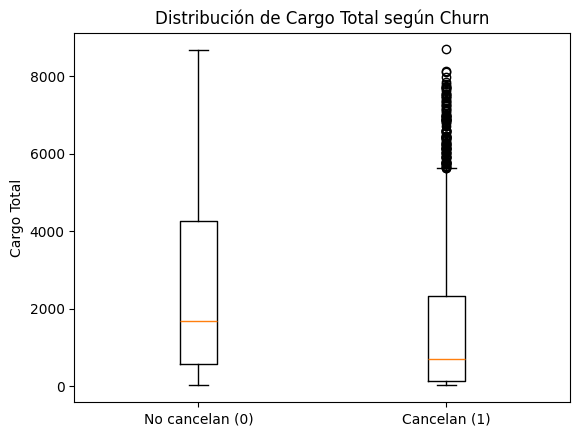

In [51]:
plt.figure()

data_cargo_total = [
    df[df['Churn'] == 0]['Cargo_Total'],
    df[df['Churn'] == 1]['Cargo_Total']
]

plt.boxplot(data_cargo_total, tick_labels=['No cancelan (0)', 'Cancelan (1)'])

plt.title("Distribución de Cargo Total según Churn")
plt.ylabel("Cargo Total")

plt.show()

El análisis de las variables numéricas muestra que los clientes que cancelan presentan una menor antigüedad y un menor cargo total acumulado en comparación con los clientes activos. La distribución evidencia que la evasión se concentra principalmente en los primeros meses del contrato, lo que sugiere que el periodo inicial del servicio es crítico para la retención del cliente.

#📄Informe final

#1. Introducción

La evasión de clientes (Churn) representa uno de los principales desafíos para las empresas de servicios, ya que implica la pérdida de ingresos y el aumento en los costos de adquisición de nuevos clientes.

El objetivo de este análisis fue identificar patrones y factores asociados a la cancelación del servicio, utilizando técnicas de análisis exploratorio de datos (EDA). A través del estudio de variables numéricas y categóricas, se buscó comprender qué características están más relacionadas con la probabilidad de evasión y generar recomendaciones estratégicas para mejorar la retención.

#2. Limpieza y Tratamiento de Datos

Durante esta etapa se realizaron los siguientes procesos:

- Importación del dataset al entorno de trabajo en Python.

- Revisión de tipos de datos y conversión de variables cuando fue necesario.

- Transformación de la variable Churn a formato numérico (0 = permanece, 1 = cancela).

- Renombramiento de columnas al español para facilitar la interpretación.

- Creación de la variable Cuentas_Diarias a partir del cargo mensual.

- Verificación de valores nulos y consistencia de la información.

Este proceso permitió garantizar que los datos fueran coherentes, interpretables y adecuados para el análisis.

#3. Análisis Exploratorio de Datos (EDA)
##📌 Distribución General del Churn

El análisis mostró que aproximadamente una cuarta parte de los clientes presentan evasión, mientras que la mayoría permanecen activos. Sin embargo, el porcentaje de cancelación es suficientemente significativo como para impactar la rentabilidad de la empresa.

##📌 Análisis de Variables Numéricas

Antigüedad (Antiguedad_meses):

Clientes activos: promedio ≈ 37.6 meses

Clientes que cancelan: promedio ≈ 17.9 meses

La cancelación se concentra principalmente en los primeros meses del servicio, lo que indica que el periodo inicial es crítico para la retención.

Cargo Mensual (Cargo_Mensual):

Clientes activos: ≈ $61

Clientes que cancelan: ≈ $74

Los clientes que cancelan pagan en promedio un cargo mensual más alto, lo que sugiere que el precio puede influir en la decisión de baja.

Cargo Total (Cargo_Total):

Los clientes que permanecen presentan un mayor cargo acumulado, lo cual es coherente con su mayor antigüedad.

##📌 Análisis de Variables Categóricas

Método de Pago:

Cheque electrónico: ≈ 45% cancelación

Métodos automáticos: entre 15% y 17%

El cheque electrónico presenta la mayor tasa de evasión, lo que sugiere que los pagos no automatizados pueden estar asociados a menor compromiso o mayor fricción en el proceso.

Tipo de Servicio de Internet:

Fibra óptica: ≈ 42% cancelación

DSL: ≈ 19%

Sin internet: ≈ 7%

Los clientes con fibra óptica presentan más del doble de cancelación que los clientes DSL, lo que podría estar relacionado con precios más altos o mayores expectativas de calidad.

Género:

No se encontraron diferencias significativas entre hombres y mujeres en términos de evasión.

#4. Conclusiones e Insights

El análisis permitió identificar los principales factores asociados al churn:

- La baja antigüedad es el factor más determinante.

- Los cargos mensuales elevados están relacionados con mayor cancelación.

- El cheque electrónico como método de pago presenta la tasa más alta de evasión.

- El servicio de fibra óptica muestra un riesgo considerablemente mayor de cancelación.

- El género no influye de manera significativa.

##🎯 Perfil del cliente con mayor probabilidad de churn:

Cliente con baja antigüedad, cargo mensual alto, servicio de fibra óptica y método de pago mediante cheque electrónico.

#5. Recomendaciones Estratégicas

Con base en los hallazgos, se proponen las siguientes acciones:

1. Fortalecer la retención en los primeros meses, implementando programas de acompañamiento o beneficios iniciales.

2. Incentivar métodos de pago automáticos, ofreciendo descuentos o beneficios por domiciliación.

3. Revisar la estrategia de precios y calidad del servicio de fibra óptica, especialmente en comparación con la competencia.

4. Implementar campañas de fidelización dirigidas a clientes con alta facturación mensual.

5. Desarrollar modelos predictivos para identificar clientes en riesgo antes de que cancelen.

#Conclusión Final

El análisis de datos permitió identificar patrones claros asociados a la evasión de clientes. Estos hallazgos proporcionan información valiosa para la toma de decisiones estratégicas orientadas a reducir la cancelación y mejorar la rentabilidad del negocio.